In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
from langchain_openai import ChatOpenAI
from openai import OpenAI

In [6]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph,START,END,MessagesState

In [ ]:
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from pinecone.grpc import PineconeGRPC
from qdrant_client import QdrantClient
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [31]:
pinecone_api_key=os.getenv("PINECONE_API_KEY")
pinecone_index_name=os.getenv("PINECONE_INDEX_NAME")
openai_api_key=os.getenv("OPENAI_API_KEY")
pc=PineconeGRPC(api_key=pinecone_api_key)
index_description = pc.describe_index(name=pinecone_index_name)
index = pc.Index(host=index_description.host)
qdrant_url=os.getenv("Qdrant_host")
qdrant_api_key = os.getenv("Qdrant_api_key")
qdrant_client = QdrantClient(
    url=qdrant_url,
    api_key=qdrant_api_key)

In [178]:
llm=ChatOpenAI(model="gpt-4o-mini")

In [94]:
system_promot = """
You are a helpfull assitant.
you have the access to two different vector database, one  vector database contains infrormation about HR policies 
and another vector database that contains information about case verdicts.
you can query the database with a question and get the most relevant information about it, 
you can use this information to answer the user's question.
If the question is about HR policies, you should query the HR policies database, 
and if the question is about case verdicts, you should query the case verdicts database.

If the user question is not about HR policies or case verdicts, 
pls asnswer the question as I don't have access to any other information except for HR policies and case verdicts.
"""

In [95]:
system_message=SystemMessage(content=system_promot)

In [98]:
from typing import List

In [122]:
class State(MessagesState):
    question: str
    retrieved_docs: List[str]
    generated_docs: str
    router_decision: str

In [123]:
def AgentState(state:State):
    state_info=state["messages"]
    user_message=state_info[-1]
    return {
        "messages": state_info,
        "question": user_message.content,
        "retrieved_docs": state.get("retrieved_docs",[]),
        "generated_docs": state.get("generated_docs",""),
        "router_decision": state.get("router_decision","")
    }

In [124]:
router_prompt = """
You are a query classification assistant.

Your task is to classify the user’s question into exactly ONE of the following categories 
based strictly on its intent.

Available knowledge sources:
1. HR_POLICY  → Questions related to company HR policies (stored in Pinecone index).
2. LAW_CASE   → Questions related to historical court cases or legal verdicts 
(stored in Qdrant collection).
3. UNKNOWN    → Questions that do not clearly belong to HR policies or legal case verdicts.

Instructions:
- Carefully analyze the user question.
- Classify based on the primary intent of the question.
- Do NOT answer the question.
- Do NOT explain your reasoning.
- Do NOT hallucinate.
- Output ONLY one of the following exact labels:
  HR_POLICY
  LAW_CASE
  UNKNOWN

User Question:
{question}
"""

In [160]:
def router_decision(state:State):
    """
    This Function classifies the user question into 3 category using LLM
    1. HR Ploicy
    2. Law case
    3.  
    """
    question=state["question"]
    prompt = ChatPromptTemplate.from_template(router_prompt)
    chain = prompt | llm | StrOutputParser()
    response = chain.invoke({"question":question})
    return {
         "router_decision": response
    }

In [161]:
def route_selector(state: State):
    return state["router_decision"]

In [162]:
def HR_retrieval(state:State):
    """
    This function used to retrieve similar documents related to HR policy related question.
    It will first convert the question into vector and
    then use the vector to retrieve similar documents from pinecone collection.
    """
    question=state["question"]
    embedding_client = OpenAI(api_key=openai_api_key)
    query_emded=embedding_client.embeddings.create(
        input=question,
        model="text-embedding-3-small",
        encoding_format="float"
    )
    query_vector=query_emded.data[0].embedding
    answer = index.query(
        vector=query_vector,
        top_k=2,
        include_metadata=True
    )
    return {
        "retrieved_docs": "\n\n".join(i.metadata["text"] for i in answer.matches)
    }
    

In [163]:
def law_retrieval(state:State):
    """
    This function used to retrieve similar documents related to Court case related question.
     It will first convert the question into vector and
    then use the vector to retrieve similar documents from qdrant collection.
    """
    question=state["question"]
    embedding_client = OpenAI(api_key=openai_api_key)
    query_emded=embedding_client.embeddings.create(
        input=question,
        model="text-embedding-3-small",
        encoding_format="float"
    )
    query_vector=query_emded.data[0].embedding
    answer=qdrant_client.query_points(
        query=query_vector,
        limit=2,
        collection_name="law_policy_collection"
    )
    return {
        "retrieved_docs": "\n\n".join(i.payload["text"] for i in answer.points)
    }

In [168]:
final_prompt ="""
You are a helpful assistant.
you need to answer the user's question based on the retrieved documents.
Be precise and concise in your answer, and only include information 
that is relevant to the user's question.
if the answer is not in the retrieved documents, say you don't know instead 
of hallucinating an answer.

retrieved documents:
{retrieved_docs}
user question:
{question}
"""

In [169]:
def generation(state:State):
    """
    This function used to generate answer based on the retrieved documents and user question."""

    question=state["question"]
    retrieved_docs=state["retrieved_docs"]
    prompt = ChatPromptTemplate.from_template(final_prompt)
    chain = prompt | llm | StrOutputParser()
    response = chain.invoke({"question":question,"retrieved_docs":retrieved_docs})
    return {
            "generated_docs": response
    }

In [170]:
graph = StateGraph(State)
graph.add_node("Receiver",AgentState)
graph.add_node("Router",router_decision)
graph.add_node("HR_Retrieval",HR_retrieval)
graph.add_node("Law_Retrieval",law_retrieval)
graph.add_node("Generation",generation)
graph.add_edge(START,"Receiver")
graph.add_edge("Receiver","Router")
graph.add_conditional_edges(
    "Router",
    route_selector,
    {
        "HR_POLICY": "HR_Retrieval",
        "LAW_CASE": "Law_Retrieval",
        "UNKNOWN": END
    }
)
graph.add_edge("HR_Retrieval", "Generation")
graph.add_edge("Law_Retrieval", "Generation")
graph.add_edge("Generation", END)
app=graph.compile()


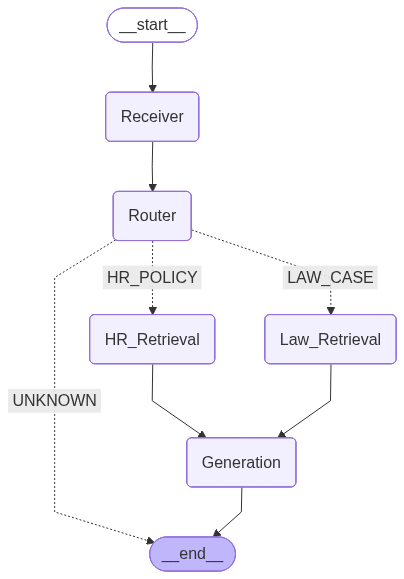

In [171]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [175]:
response=app.invoke({
    "messages":[
        HumanMessage(content="what is working hours as per policy?")
    ]
})

In [176]:
print(response['generated_docs']) #response['generated_docs']

The standard working hours are 9:00 AM to 6:00 PM, Monday through Friday.


With Human feed back

In [179]:
from langgraph.checkpoint.memory import MemorySaver

In [180]:
memory = MemorySaver()

In [207]:
graph1 = StateGraph(State)
graph1.add_node("Receiver",AgentState)
graph1.add_node("Router",router_decision)
graph1.add_node("HR_Retrieval",HR_retrieval)
graph1.add_node("Law_Retrieval",law_retrieval)
graph1.add_node("Generation",generation)
graph1.add_edge(START,"Receiver")
graph1.add_edge("Receiver","Router")
graph1.add_conditional_edges(
    "Router",
    route_selector,
    {
        "HR_POLICY": "HR_Retrieval",
        "LAW_CASE": "Law_Retrieval",
        "UNKNOWN": END
    }
)
graph1.add_edge("HR_Retrieval", "Generation")
graph1.add_edge("Law_Retrieval", "Generation")
graph1.add_edge("Generation", END)
app=graph1.compile(interrupt_after=["Router"], checkpointer=memory)

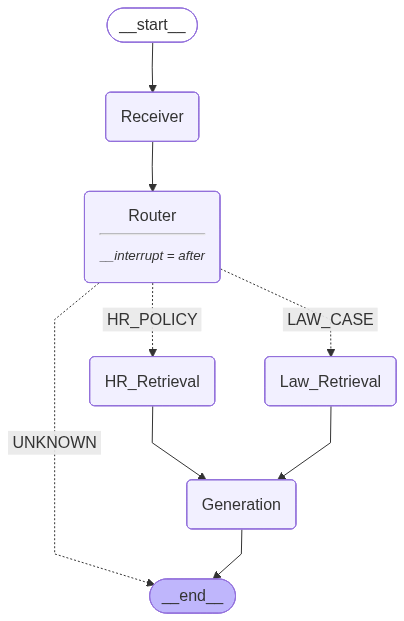

In [208]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [225]:
thread = {"configurable": {"thread_id": "6"}}

In [226]:
qus={"messages": ["what is working hours as per policy?"]}

In [227]:
for event in app.stream(qus, thread, stream_mode="values"):
    print(event.get('router_decision',""))



HR_POLICY


In [228]:
app.update_state(
    thread,
    {"router_decision": "LAW_CASE"},
)

{'configurable': {'thread_id': '6',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10e48c-c67a-6421-8003-6ee1724044f8'}}

In [229]:
for event in app.stream(None, thread, stream_mode="values"):
    print(event.get("router_decision", ""))
    print(event.get("generated_docs", ""))

LAW_CASE

LAW_CASE

LAW_CASE
I don't know.


if stream not need, we can use 
app.invoke(None, config=config)